In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

# **Parameter initialization and data preparation**

In [2]:
# Parameters
batch_size = 8
num_epochs = 5
device = 'cuda:0'
num_classes = 10

# Load dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
valset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

print(trainset)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.06MB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )


In [3]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize to show images correctly
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

torch.Size([8, 1, 28, 28])


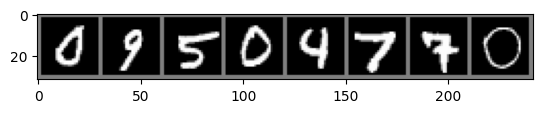

    0     9     5     0     4     7     7     0


In [4]:
# Print some samples of dataset as a sanity check

# Get some random training images
dataiter = iter(trainloader)
example_images, example_labels = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))

# **Define Models**

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # >> Your code goes here <<

    def forward(self, x):
        # >> Your code goes here <<
        return x

# **Make a training loop**

In [6]:
def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
# Instantiate model and optimizer

model = Autoencoder().to(device)

print("Number of trainable parameters: {}".format(count_parameters(model)))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = np.inf

tr_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

for epoch_nr in range(num_epochs):

    print("Epoch {}:".format(epoch_nr))

    # Train model
    running_loss = 0.0
    # Train model
    # >> Your code goes here <<
    # You can re-use code from previous exercises but don't forget that we
    # the input image is also the label

    # Print results
    tr_loss = running_loss/len(trainloader.dataset)
    print('>> TRAIN: Epoch {} completed | tr_loss: {:.4f}'.format(
        epoch_nr, running_loss/len(trainloader.dataset)))

    # Get validation results
    running_loss = 0
    # >> Your code goes here <<

    val_loss = running_loss/len(valloader.dataset)
    print('>> VALIDATION: Epoch {} | val_loss: {:.4f}'.format(epoch_nr, val_loss))

    tr_losses[epoch_nr] = tr_loss
    val_losses[epoch_nr] = val_loss

print('Training finished')

Number of trainable parameters: 0


ValueError: optimizer got an empty parameter list

# **Investigate results**

In [ ]:
plt.figure()
plt.plot(tr_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.title('Results')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [ ]:
# Check some reconstructions by the trained model

# Get some random validation images
dataiter = iter(valloader)
example_images, _ = dataiter.next()

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
preds = model(example_images.to(device))
imshow(torchvision.utils.make_grid(preds.cpu()))
# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))